# About this notebook

**Prepared by:** Maryam Hiradfar  
MD–PhD Candidate, Harvard Medical School & Harvard Biophysics  
Catana Lab | Martinos Center for Biomedical Imaging

This notebook serves as an introduction to the PET simulation and dual-tracer separation framework used throughout this repository. The goal is to familiarize new lab members with both the PET concepts and the software architecture before contributing to the codebase.

Last updated: June 17 2026

# PET TAC Simulation Walkthrough

This notebook walks through the basic building blocks of PET time–activity curve (TAC) simulation using the existing codebase.

By the end, you should understand:

1. what an arterial input function (AIF) represents,
2. how a tissue TAC is generated from a kinetic model,
3. how continuous TACs are converted into PET frame averages,
4. how physical decay and measurement noise affect observed PET data,
5. how two tracer signals can be combined with an injection delay,
6. how a dictionary/basis-based separation algorithm can be applied.

The notebook is meant to be run from the root directory of the repository.

## 0. Setup

Run this notebook from the root of the repository, so that imports like `tracers.fdg`, `sim.tac_simulator`, and `kinetics.models.twotcm` work correctly.

If imports fail, first check that:

- the notebook is running inside the correct Python environment,
- the repository root is on `sys.path`,
- the repo has been installed with `pip install -e .` if you are using editable installation.

In [1]:
from pathlib import Path
import sys

# Optional: add repository root manually if needed.
# If this notebook is placed inside notebooks/, this points one level up.
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

Repository root: /Users/maryamhiradfar/Documents/GitHub/dual_tracer_sims


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Core tracer objects
from tracers.fdg import FDGTracer
from tracers.pbr28 import PBR28Tracer

# Kinetic simulation
from kinetics.models.twotcm import simulate_2tcm

# Frame averaging and noise
from utils.frame_average import frame_average
from core.noise import add_noise_voxel

# Optional separation pieces used later
from scipy.optimize import nnls

## 1. PET TAC basics

A PET time activity curve (TAC) is a curve showing radioactivity concentration as a function of time. It is basically counts/volume as measured in either a single voxel or a single region of interest (ROI), as measured over time. A commonly used unit for each timepoint data in a TAC is kBq/mL. 
To generate a TAC for either of our tracers (FDG or PBR28), we need a few things: 

1- An arterial input function (AIF). (you can think of this as the activity of the injected dose). In gold-standard PET, people physically measure AIFs using arterial blood sampling. One of the benefits of long-axial-field-of-view (LAFOV) scanners, like Panorama GS is that they also have the arterial blood pool in the field of view (for instance the aorta). So for a lot of tracers, we can now measure something called an image-derived arterial input function instead of invasive arterial sampling. All of this is to say, that we need an estimate/ or a simulation of a "ground-truth" AIF. There are mathematical models in the literature for simulating these. One that is frequently used for FDG is called the Feng Model. For PBR28, there is no such model, but frequently people use a combination of exponential functions to simulate it. 

2- A kinetic model: a kinetic model mathematically describes how the concentration of the tracer is changing in different "compartments" for instance in a frequently-used kinetic model called the two-tissue compartment model (2TCM), the mathematical model describes the change in the concentration of the tracer in the following compartments: 
    a- plasma compartment
    b- free or non-specifically bound tracer tissue compartment
    c- specifically-bound tracer tissue compartment. 
In this notebook, we will keep track of several related curves:

- **AIF / plasma input curve**: described above, but in short:tracer concentration in blood/plasma entering tissue.
- **Biological tissue TAC**: tissue concentration predicted by the kinetic model before physical decay correction.
- **Measured-domain tissue TAC**: biological tissue signal multiplied by radioactive decay.
- **Frame-averaged TAC**: what PET frames actually approximate, because each data point averages over a time bin.
- **Noisy measured TAC**: a more realistic simulated observation after count noise.

## 2. Create a simple PET scan time grid

PET data are not usually analyzed at every instant in continuous time. Instead, the scanner reconstructs images over time frames, such as short frames early after injection and longer frames later.

Here we define:

- a fine internal time grid for smooth simulation,
- frame edges,
- frame midpoints,
- frame durations.

In [3]:
# Internal high-resolution simulation grid, in minutes
t_end = 90.0
dt = 0.05
t_int = np.arange(0, t_end + dt, dt)

# Example frame schedule:
# 4 x 15 s, 4 x 30 s, 3 x 1 min, 2 x 2 min, 5 x 4 min, 4 x 15 min
frame_durs = np.array(
    [0.25] * 4 +
    [0.50] * 4 +
    [1.00] * 3 +
    [2.00] * 2 +
    [4.00] * 5 +
    [15.00] * 4
)

frame_edges = np.concatenate([[0.0], np.cumsum(frame_durs)])
frame_mids = 0.5 * (frame_edges[:-1] + frame_edges[1:])

print("Number of frames:", len(frame_mids))
print("Total scan duration:", frame_edges[-1], "min")

Number of frames: 22
Total scan duration: 90.0 min


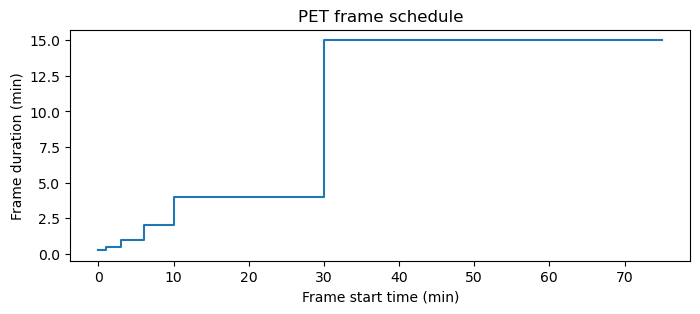

In [4]:
plt.figure(figsize=(8, 3))
plt.step(frame_edges[:-1], frame_durs, where="post")
plt.xlabel("Frame start time (min)")
plt.ylabel("Frame duration (min)")
plt.title("PET frame schedule")
plt.show()

## 3. Instantiate tracer objects

The tracer objects encapsulate two important pieces of information:

1. the tracer half-life,
2. the tracer-specific AIF function.

For this demo we use PBR28 and FDG, but the same structure can be reused for other tracers later.

In [5]:
pbr = PBR28Tracer(name="PBR28", half_life_min=20.4, scale=1.0)
fdg = FDGTracer(name="FDG", half_life_min=109.8, scale=1.0)

print(pbr)
print(fdg)

PBR28Tracer(name='PBR28', half_life_min=20.4, scale=1.0, pbr28_params={'A1': 22.0, 'A2': 3.2, 'A3': 0.25, 'lam1': 3.1, 'lam2': 0.23, 'lam3': 0.015})
FDGTracer(name='FDG', half_life_min=109.8, scale=1.0, feng_params={'A1': 1854.66, 'A2': 8.168, 'A3': 2.731, 'lam1': 20.031, 'lam2': 0.355, 'lam3': 0.0178, 'tau': 0.27})


## 4. Plot arterial input functions

The AIF describes tracer delivery to tissue. It usually has an early sharp peak followed by a slower tail.

We first plot both AIFs with injection at time zero.

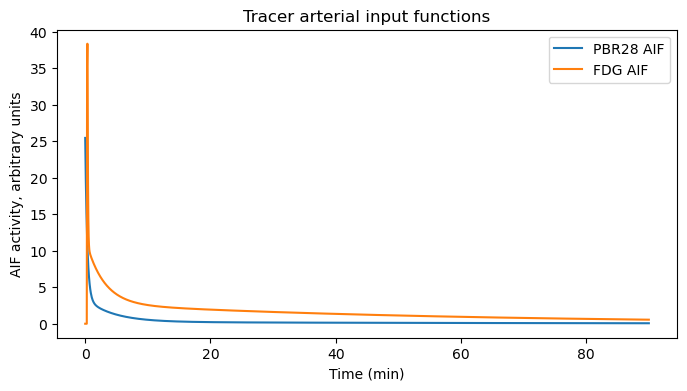

In [6]:
Cp_pbr = pbr.aif(t_int, delta_min=0.0)
Cp_fdg = fdg.aif(t_int, delta_min=0.0)

plt.figure(figsize=(8, 4))
plt.plot(t_int, Cp_pbr, label="PBR28 AIF")
plt.plot(t_int, Cp_fdg, label="FDG AIF")
plt.xlabel("Time (min)")
plt.ylabel("AIF activity, arbitrary units")
plt.title("Tracer arterial input functions")
plt.legend()
plt.show()

## 5. Simulate a single-tracer tissue TAC using 2TCM

The two-tissue compartment model has four rate parameters:

- `K1`: plasma to tissue delivery,
- `k2`: tissue to plasma efflux,
- `k3`: transfer from first tissue compartment into second tissue compartment,
- `k4`: transfer back from second tissue compartment.

The model returns:

- total tissue concentration `Ct = C1 + C2`,
- first tissue compartment `C1`,
- second tissue compartment `C2`.

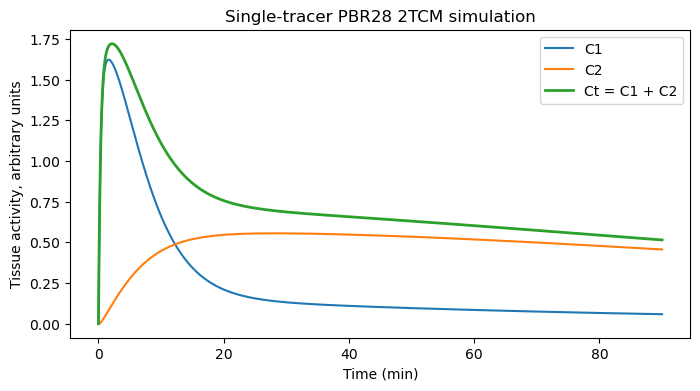

In [7]:
params_pbr = pbr.true_params()
Ct_pbr_int, C1_pbr_int, C2_pbr_int = simulate_2tcm(
    **params_pbr,
    Cp=Cp_pbr,
    t=t_int
)

plt.figure(figsize=(8, 4))
plt.plot(t_int, C1_pbr_int, label="C1")
plt.plot(t_int, C2_pbr_int, label="C2")
plt.plot(t_int, Ct_pbr_int, label="Ct = C1 + C2", linewidth=2)
plt.xlabel("Time (min)")
plt.ylabel("Tissue activity, arbitrary units")
plt.title("Single-tracer PBR28 2TCM simulation")
plt.legend()
plt.show()

## 6. Convert the smooth TAC into PET frame averages

The kinetic model is simulated on a fine time grid, but PET data are reconstructed in frames.

Here we convert the smooth biological tissue TAC into frame averages.

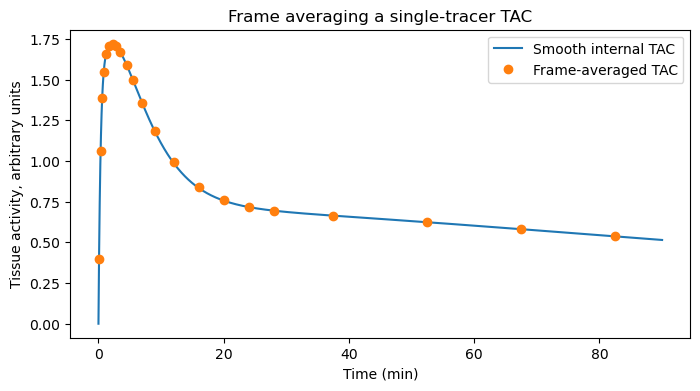

In [8]:
Ct_pbr_frame = frame_average(t_int, Ct_pbr_int, frame_edges)

plt.figure(figsize=(8, 4))
plt.plot(t_int, Ct_pbr_int, label="Smooth internal TAC")
plt.plot(frame_mids, Ct_pbr_frame, "o", label="Frame-averaged TAC")
plt.xlabel("Time (min)")
plt.ylabel("Tissue activity, arbitrary units")
plt.title("Frame averaging a single-tracer TAC")
plt.legend()
plt.show()

## 7. Apply radioactive decay

The biological TAC is what the tissue model predicts. The scanner measures radioactive emissions, so the observed contribution is reduced by physical decay.

For a tracer with half-life $T_{1/2}$:

$$
\lambda = \frac{\ln 2}{T_{1/2}}
$$

and the measured-domain signal is:

$$
C_{meas}(t) = C_{bio}(t)e^{-\lambda t}
$$

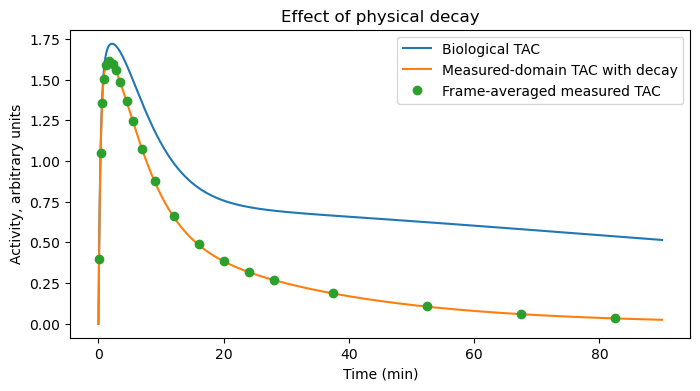

In [9]:
lam_pbr = np.log(2.0) / pbr.half_life_min
decay_pbr_int = np.exp(-lam_pbr * t_int)

Ct_pbr_phys_int = Ct_pbr_int * decay_pbr_int
Ct_pbr_phys_frame = frame_average(t_int, Ct_pbr_phys_int, frame_edges)

plt.figure(figsize=(8, 4))
plt.plot(t_int, Ct_pbr_int, label="Biological TAC")
plt.plot(t_int, Ct_pbr_phys_int, label="Measured-domain TAC with decay")
plt.plot(frame_mids, Ct_pbr_phys_frame, "o", label="Frame-averaged measured TAC")
plt.xlabel("Time (min)")
plt.ylabel("Activity, arbitrary units")
plt.title("Effect of physical decay")
plt.legend()
plt.show()

## 8. Add simple PET count noise

PET data are noisy because detected counts are stochastic. Your codebase has a voxel-level noise function that approximates Poisson count noise.

The exact noise level depends on scanner sensitivity, voxel size, activity concentration, and frame duration.

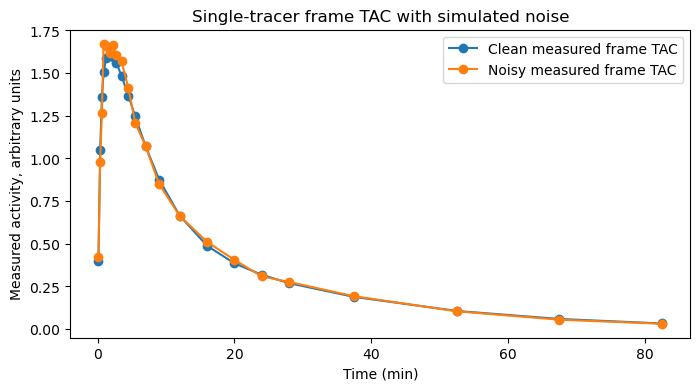

Expected counts per frame:
[  67.23024454  177.71334716  229.88982747  254.70205726  537.87794763
  545.95545019  539.90687112  527.51755991 1004.49153744  925.99198644
  843.497341   1452.53588014 1185.13676777 1799.08971419 1322.23476097
 1043.75381367  862.03364918  728.65149826 1915.19074819 1079.75478671
  604.43428539  335.64756159]


In [10]:
rng = np.random.default_rng(123)

Ct_pbr_noisy_frame, expected_counts = add_noise_voxel(
    Ct_pbr_phys_frame,
    frame_durs,
    voxel_size_mm=4.0,
    scanner_name="panorama_gs",
    rng=rng,
)

plt.figure(figsize=(8, 4))
plt.plot(frame_mids, Ct_pbr_phys_frame, "o-", label="Clean measured frame TAC")
plt.plot(frame_mids, Ct_pbr_noisy_frame, "o-", label="Noisy measured frame TAC")
plt.xlabel("Time (min)")
plt.ylabel("Measured activity, arbitrary units")
plt.title("Single-tracer frame TAC with simulated noise")
plt.legend()
plt.show()

print("Expected counts per frame:")
print(expected_counts)

## 9. Simulate a second tracer with an injection delay

For dual-tracer PET, the second tracer can be injected later than the first. We represent that by evaluating its AIF at relative time:

$$
t_{rel,2} = \max(t - \Delta, 0)
$$

where $\Delta$ is the delay between injections.

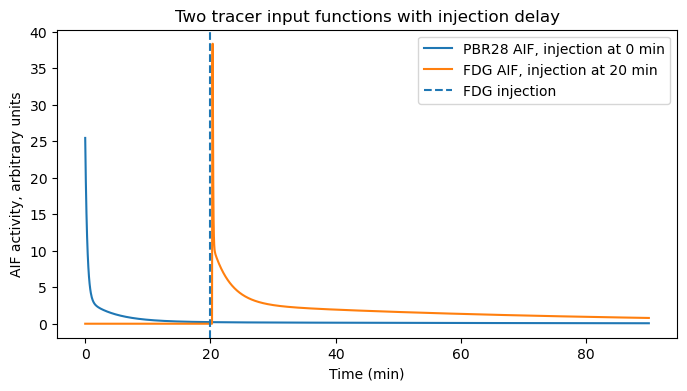

In [11]:
Delta = 20.0  # minutes between PBR28 and FDG injections

Cp_fdg_delayed = fdg.aif(t_int, delta_min=Delta)

Ct_fdg_int, C1_fdg_int, C2_fdg_int = simulate_2tcm(
    **fdg.true_params(),
    Cp=Cp_fdg_delayed,
    t=t_int
)

plt.figure(figsize=(8, 4))
plt.plot(t_int, Cp_pbr, label="PBR28 AIF, injection at 0 min")
plt.plot(t_int, Cp_fdg_delayed, label=f"FDG AIF, injection at {Delta:g} min")
plt.axvline(Delta, linestyle="--", label="FDG injection")
plt.xlabel("Time (min)")
plt.ylabel("AIF activity, arbitrary units")
plt.title("Two tracer input functions with injection delay")
plt.legend()
plt.show()

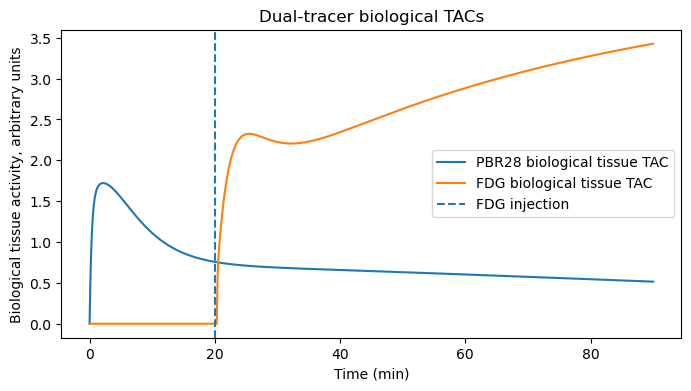

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t_int, Ct_pbr_int, label="PBR28 biological tissue TAC")
plt.plot(t_int, Ct_fdg_int, label="FDG biological tissue TAC")
plt.axvline(Delta, linestyle="--", label="FDG injection")
plt.xlabel("Time (min)")
plt.ylabel("Biological tissue activity, arbitrary units")
plt.title("Dual-tracer biological TACs")
plt.legend()
plt.show()

## 10. Generate the measured dual-tracer signal

The scanner does not directly know which detected positron came from which tracer. In a conventional PET measurement, the measured signal is approximately the sum of both measured-domain tracer contributions.

Each tracer should be decayed relative to its own injection time.

In [13]:
# Biological frame averages
Ct1_bio_frame = frame_average(t_int, Ct_pbr_int, frame_edges)
Ct2_bio_frame = frame_average(t_int, Ct_fdg_int, frame_edges)

# Decay relative to injection time
lam1 = np.log(2.0) / pbr.half_life_min
lam2 = np.log(2.0) / fdg.half_life_min

t_rel1_int = t_int
t_rel2_int = np.maximum(t_int - Delta, 0.0)

decay1_int = np.exp(-lam1 * t_rel1_int)
decay2_int = np.exp(-lam2 * t_rel2_int)

Ct1_phys_int = Ct_pbr_int * decay1_int
Ct2_phys_int = Ct_fdg_int * decay2_int

y_clean_int = Ct1_phys_int + Ct2_phys_int
y_clean_frame = frame_average(t_int, y_clean_int, frame_edges)

y_noisy_frame, expected_counts_dual = add_noise_voxel(
    y_clean_frame,
    frame_durs,
    voxel_size_mm=4.0,
    scanner_name="panorama_gs",
    rng=np.random.default_rng(456),
)

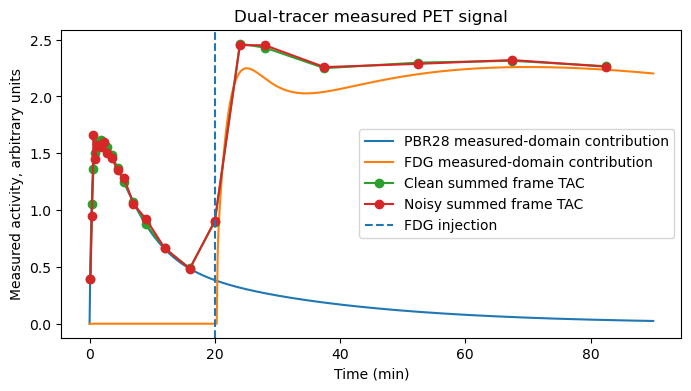

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(t_int, Ct1_phys_int, label="PBR28 measured-domain contribution")
plt.plot(t_int, Ct2_phys_int, label="FDG measured-domain contribution")
plt.plot(frame_mids, y_clean_frame, "o-", label="Clean summed frame TAC")
plt.plot(frame_mids, y_noisy_frame, "o-", label="Noisy summed frame TAC")
plt.axvline(Delta, linestyle="--", label="FDG injection")
plt.xlabel("Time (min)")
plt.ylabel("Measured activity, arbitrary units")
plt.title("Dual-tracer measured PET signal")
plt.legend()
plt.show()

## 11. Build simple gamma basis libraries

A basis library is a collection of plausible TAC-like curves. Here we use gamma-shaped curves as simple flexible building blocks.

Each basis function has:

- an onset time `t0`,
- a time-scale parameter `tau`.

Later, separation algorithms try to explain the observed mixed TAC as a nonnegative combination of basis functions from tracer 1 and tracer 2.

In [15]:
from kinetics.helpers.basis_gamma import gamma_shape

def build_demo_gamma_library(t, t0_values, tau_values, scale=1.0):
    basis = []
    params = []
    for t0 in t0_values:
        for tau in tau_values:
            basis.append(gamma_shape(t, t0, tau, scale=scale))
            params.append((t0, tau))
    return np.asarray(basis), params

t0_values_1 = np.linspace(0, 10, 5)
t0_values_2 = np.linspace(Delta - 5, Delta + 5, 5)
tau_values = np.linspace(2, 40, 8)

lib1_bio, params1 = build_demo_gamma_library(frame_mids, t0_values_1, tau_values)
lib2_bio, params2 = build_demo_gamma_library(frame_mids, t0_values_2, tau_values)

decay1_frame = np.exp(-lam1 * frame_mids)
decay2_frame = np.exp(-lam2 * np.maximum(frame_mids - Delta, 0.0))

Phi1 = (lib1_bio * decay1_frame[np.newaxis, :]).T
Phi2 = (lib2_bio * decay2_frame[np.newaxis, :]).T

print("Phi1 shape:", Phi1.shape)
print("Phi2 shape:", Phi2.shape)

Phi1 shape: (22, 40)
Phi2 shape: (22, 40)


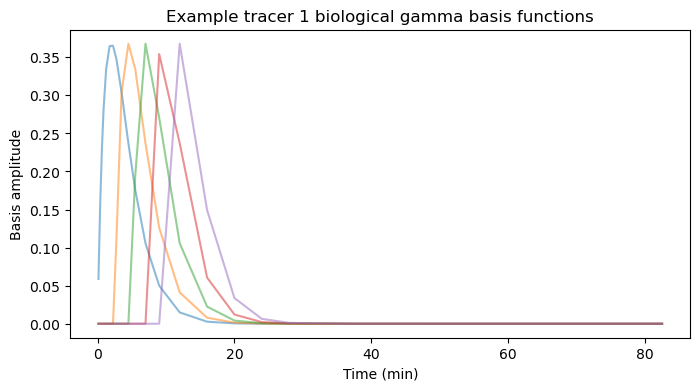

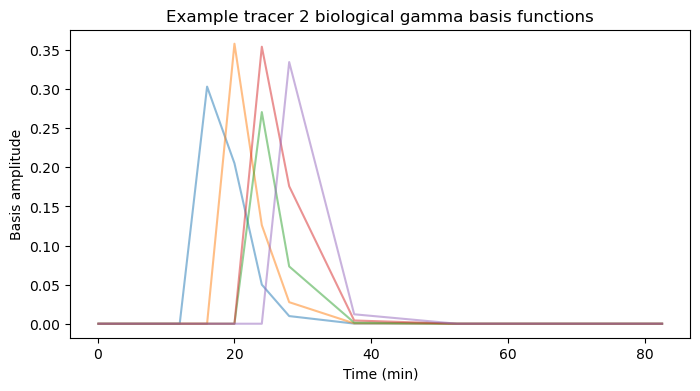

In [16]:
plt.figure(figsize=(8, 4))
for row in lib1_bio[::8]:
    plt.plot(frame_mids, row, alpha=0.5)
plt.xlabel("Time (min)")
plt.ylabel("Basis amplitude")
plt.title("Example tracer 1 biological gamma basis functions")
plt.show()

plt.figure(figsize=(8, 4))
for row in lib2_bio[::8]:
    plt.plot(frame_mids, row, alpha=0.5)
plt.xlabel("Time (min)")
plt.ylabel("Basis amplitude")
plt.title("Example tracer 2 biological gamma basis functions")
plt.show()

## 12. Demonstrate simple joint NNLS separation

This is a simple baseline algorithm.

We concatenate the two tracer basis matrices:

$$
y \approx \Phi_1 w_1 + \Phi_2 w_2
$$

and solve for nonnegative coefficients:

$$
w_1, w_2 \ge 0
$$

This is not necessarily the final best algorithm, but it is useful pedagogically because it shows the core idea of dictionary-based unmixing.

In [17]:
A = np.concatenate([Phi1, Phi2], axis=1)
w, residual_norm = nnls(A, y_noisy_frame)

n1 = Phi1.shape[1]
w1 = w[:n1]
w2 = w[n1:]

tracer1_est_meas = Phi1 @ w1
tracer2_est_meas = Phi2 @ w2
y_fit = tracer1_est_meas + tracer2_est_meas

print("Residual norm:", residual_norm)
print("Number of active tracer 1 coefficients:", np.sum(w1 > 1e-8))
print("Number of active tracer 2 coefficients:", np.sum(w2 > 1e-8))

Residual norm: 0.7278383525177504
Number of active tracer 1 coefficients: 5
Number of active tracer 2 coefficients: 5


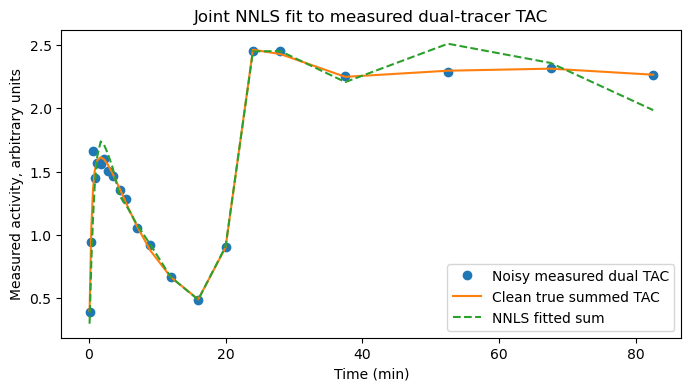

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(frame_mids, y_noisy_frame, "o", label="Noisy measured dual TAC")
plt.plot(frame_mids, y_clean_frame, "-", label="Clean true summed TAC")
plt.plot(frame_mids, y_fit, "--", label="NNLS fitted sum")
plt.xlabel("Time (min)")
plt.ylabel("Measured activity, arbitrary units")
plt.title("Joint NNLS fit to measured dual-tracer TAC")
plt.legend()
plt.show()

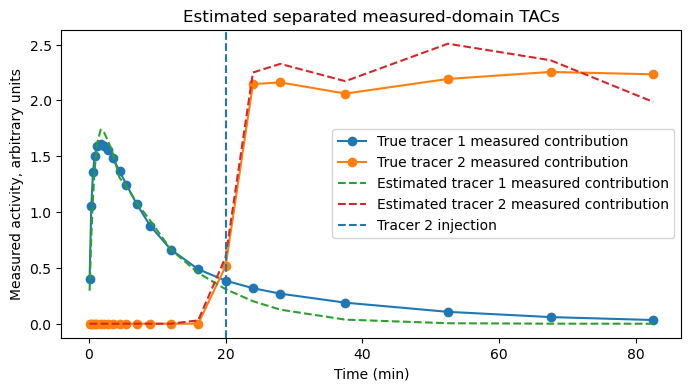

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(frame_mids, frame_average(t_int, Ct1_phys_int, frame_edges), "o-", label="True tracer 1 measured contribution")
plt.plot(frame_mids, frame_average(t_int, Ct2_phys_int, frame_edges), "o-", label="True tracer 2 measured contribution")
plt.plot(frame_mids, tracer1_est_meas, "--", label="Estimated tracer 1 measured contribution")
plt.plot(frame_mids, tracer2_est_meas, "--", label="Estimated tracer 2 measured contribution")
plt.axvline(Delta, linestyle="--", label="Tracer 2 injection")
plt.xlabel("Time (min)")
plt.ylabel("Measured activity, arbitrary units")
plt.title("Estimated separated measured-domain TACs")
plt.legend()
plt.show()

## 13. Convert separated measured-domain curves back to biological TACs

After separation, the estimated curves are still in the measured domain. To compare with the biological ground truth, undo the physical decay.

For tracer 1:

$$
C_{bio,1}(t) = C_{meas,1}(t)e^{\lambda_1 t}
$$

For tracer 2:

$$
C_{bio,2}(t) = C_{meas,2}(t)e^{\lambda_2 \max(t-\Delta,0)}
$$

In [20]:
Ct1_est_bio_frame = tracer1_est_meas * np.exp(lam1 * frame_mids)
Ct2_est_bio_frame = tracer2_est_meas * np.exp(lam2 * np.maximum(frame_mids - Delta, 0.0))

def nrmse(y_true, y_pred, eps=1e-6):
    return np.sqrt(np.mean((y_true - y_pred)**2)) / (np.max(y_true) + eps)

err1 = nrmse(Ct1_bio_frame, Ct1_est_bio_frame)
err2 = nrmse(Ct2_bio_frame, Ct2_est_bio_frame)

print(f"Tracer 1 biological NRMSE: {err1:.3f}")
print(f"Tracer 2 biological NRMSE: {err2:.3f}")

Tracer 1 biological NRMSE: 0.162
Tracer 2 biological NRMSE: 0.039


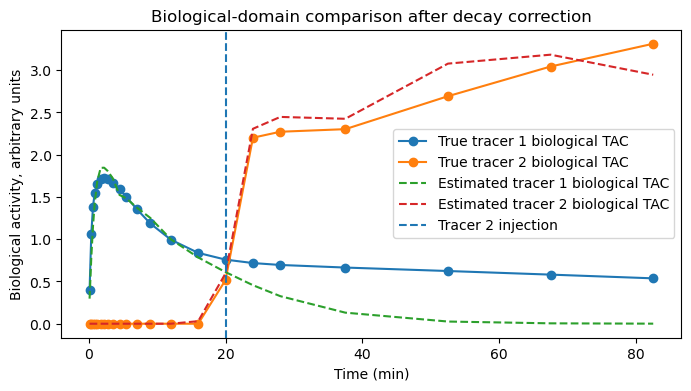

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(frame_mids, Ct1_bio_frame, "o-", label="True tracer 1 biological TAC")
plt.plot(frame_mids, Ct2_bio_frame, "o-", label="True tracer 2 biological TAC")
plt.plot(frame_mids, Ct1_est_bio_frame, "--", label="Estimated tracer 1 biological TAC")
plt.plot(frame_mids, Ct2_est_bio_frame, "--", label="Estimated tracer 2 biological TAC")
plt.axvline(Delta, linestyle="--", label="Tracer 2 injection")
plt.xlabel("Time (min)")
plt.ylabel("Biological activity, arbitrary units")
plt.title("Biological-domain comparison after decay correction")
plt.legend()
plt.show()

## 15. Exercises

Try changing one thing at a time and re-running the notebook.

Suggested exercises:

1. Change the injection delay `Delta` from 20 min to 5, 10, 30, and 45 min. What happens to separation?
2. Increase or decrease the number of PET frames. How does frame schedule affect performance?
3. Change FDG or PBR28 kinetic parameters in `true_params`. Which parameters most affect the TAC shape?
4. Change the gamma basis library density. What happens if there are too few basis functions?
5. Turn off noise and compare separation performance.
6. Increase voxel size in `add_noise_voxel`. What happens to expected counts and TAC noise?
7. Replace the simple joint NNLS block with one of the registered separation algorithms.

## 16. Key takeaways

- PET TACs are time courses of radioactivity concentration.
- AIFs drive tissue kinetics through compartment models.
- PET frames are averages over time windows, not instantaneous samples.
- Dual-tracer PET produces a summed measured signal unless there is additional information to distinguish tracers.
- Injection timing, kinetic differences, physical decay, and basis design all help separation.
- A simple NNLS basis method is a useful baseline before testing more complex algorithms.